# MHC pseudosequence (MPS) vs. peptide contacts

NetMHCpan defines a 34-residue **pseudosequence** per allele — the polymorphic groove
positions thought to line the peptide-binding cleft. `tcren.mhc.annotate_pseudo` marks those
residues (region `MPS`) on a structure by threading the best-matching pseudosequence through
the MHC chain(s) with a fitting alignment (class I → MHCa; class II → split across MHCa+MHCb).

Here we check, on committed test structures, whether the MPS residues are really the ones in
contact with the peptide — i.e. whether the NetMHCpan groove definition recovers the structural
interface.

In [1]:
# Environment + imports
import sys, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tcren
from tcren.structure.io import import_structure
from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc, annotate_pseudo
print('python', platform.python_version(), '| numpy', np.__version__, '| matplotlib', matplotlib.__version__)

python 3.11.15 | numpy 2.4.6 | matplotlib 3.11.0


In [2]:
# Helper: annotate a test structure and return per-MHC-groove-residue min distance to the
# peptide, with a flag for whether the residue is part of the MPS pseudosequence.
ASSETS = '../tests/assets/pdb'

def min_dist_to_peptide(structure, cutoff_chains=('MHCa', 'MHCb')):
    pep = [c for c in structure.chains if c.chain_type == 'PEPTIDE']
    pa = np.vstack([a.coord for c in pep for r in c.residues for a in r.atoms])
    rows = []
    for chain in structure.chains:
        if chain.chain_type not in cutoff_chains:
            continue
        mps = {r.seq_index for reg in chain.regions if reg.region_type == 'MPS' for r in reg.residues}
        for res in chain.residues:
            ra = np.array([a.coord for a in res.atoms])
            if not len(ra):
                continue
            d = float(np.sqrt(((ra[:, None, :] - pa[None, :, :]) ** 2).sum(-1).min()))
            rows.append((chain.chain_id, res.seq_index, d, res.seq_index in mps))
    return rows

def load(pdb, organism='human'):
    s = import_structure(f'{ASSETS}/{pdb}.pdb', pdb_id=pdb)
    classify_chains(s, organism=organism)
    annotate_mhc(s)
    best = annotate_pseudo(s)
    cls = 'MHC-II' if any(c.chain_type == 'MHCb' for c in s.chains) else 'MHC-I'
    return s, best, cls

/opt/homebrew/anaconda3/envs/tcren-nb/lib/python3.11/site-packages/Bio/Align/__init__.py:4413: BiopythonDeprecationWarning: The attribute 'query_internal_open_gap_score' was renamed to 'open_internal_deletion_score'. This was done to be consistent with the
AlignmentCounts object returned by the .counts method of an Alignment object.
  warnings.warn(
/opt/homebrew/anaconda3/envs/tcren-nb/lib/python3.11/site-packages/Bio/Align/__init__.py:4413: BiopythonDeprecationWarning: The attribute 'query_internal_extend_gap_score' was renamed to 'extend_internal_deletion_score'. This was done to be consistent with the
AlignmentCounts object returned by the .counts method of an Alignment object.
  warnings.warn(
/opt/homebrew/anaconda3/envs/tcren-nb/lib/python3.11/site-packages/Bio/Align/__init__.py:4413: BiopythonDeprecationWarning: The attribute 'target_internal_open_gap_score' was renamed to 'open_internal_insertion_score'. This was done to be consistent with the
AlignmentCounts object returned b

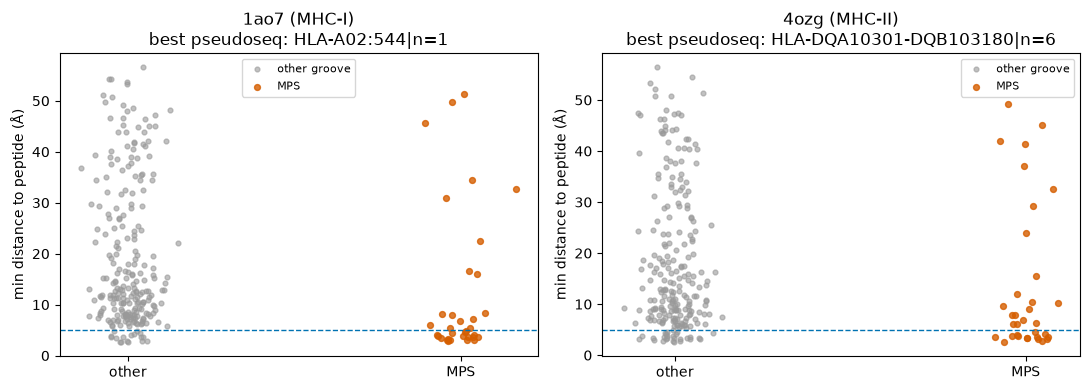

In [3]:
# Plot A: per-residue min-distance-to-peptide for the MHC groove chains of an MHC-I (1ao7)
# and an MHC-II (4ozg) complex; MPS residues highlighted. MPS points should sit low (close to
# the peptide) relative to the bulk of groove residues.
examples = [('1ao7', 'human'), ('4ozg', 'human')]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (pdb, org) in zip(axes, examples):
    s, best, cls = load(pdb, org)
    rows = min_dist_to_peptide(s)
    other = [d for _, _, d, m in rows if not m]
    mps = [d for _, _, d, m in rows if m]
    ax.scatter(np.random.normal(0, 0.05, len(other)), other, s=12, color='#999999', alpha=0.6, label='other groove')
    ax.scatter(np.random.normal(1, 0.05, len(mps)), mps, s=18, color='#D55E00', alpha=0.8, label='MPS')
    ax.axhline(5.0, ls='--', lw=1, color='#0072B2')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['other', 'MPS'])
    ax.set_ylabel('min distance to peptide (Å)')
    ax.set_title(f'{pdb} ({cls})\nbest pseudoseq: {best}')
    ax.legend(fontsize=8)
fig.tight_layout()

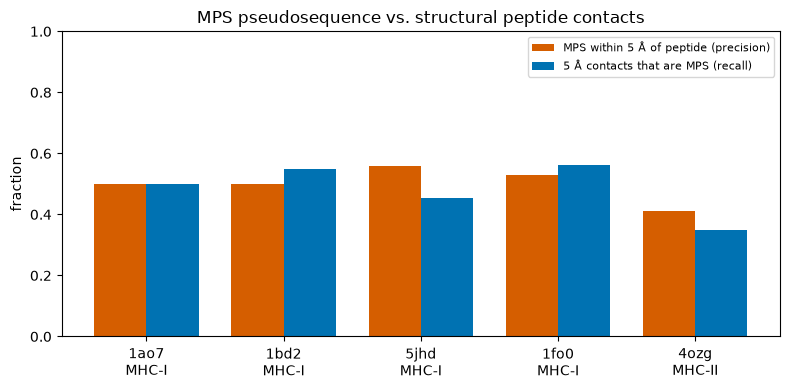

In [4]:
# Plot B: across several test complexes, what fraction of MPS residues are within 5 Å of the
# peptide (precision), and what fraction of the 5-Å peptide-contacting MHC residues are MPS
# (recall). MPS captures the groove-lining residues; ~half are direct (<5 Å) peptide contacts.
panel = [('1ao7', 'human'), ('1bd2', 'human'), ('5jhd', 'human'), ('1fo0', 'mouse'), ('4ozg', 'human')]
labels, precision, recall = [], [], []
for pdb, org in panel:
    s, best, cls = load(pdb, org)
    rows = min_dist_to_peptide(s)
    mps = [(d <= 5.0) for _, _, d, m in rows if m]
    contact_is_mps = [m for _, _, d, m in rows if d <= 5.0]
    labels.append(f'{pdb}\n{cls}')
    precision.append(np.mean(mps) if mps else 0)
    recall.append(np.mean(contact_is_mps) if contact_is_mps else 0)

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, precision, w, color='#D55E00', label='MPS within 5 Å of peptide (precision)')
ax.bar(x + w / 2, recall, w, color='#0072B2', label='5 Å contacts that are MPS (recall)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1); ax.set_ylabel('fraction')
ax.set_title('MPS pseudosequence vs. structural peptide contacts')
ax.legend(fontsize=8, loc='upper right')
fig.tight_layout()

**Reading the plots.** MPS residues sit markedly closer to the peptide than the rest of the
groove (Plot A), and roughly half of them are direct (<5 Å) peptide contacts (Plot B). The
NetMHCpan pseudosequence captures the peptide-binding groove well; the residues it does *not*
place within 5 Å are the groove-lining positions that point toward the TCR or sit at the cleft
ends — still part of the functional groove, just not in van-der-Waals contact with this peptide.